# 03 - Stage 1 Pre-training (Colab A100)
Run masked generative pre-training for REACT.

## Setup Instructions
Before running this notebook:
1. Upload your data zip to Google Drive at: `MyDrive/CiteMind/data.zip`
   - Zip locally (PowerShell): `Compress-Archive -Path src\data -DestinationPath audiocite_data.zip`
2. Set runtime to **A100 GPU**: Runtime → Change runtime type → A100 GPU
3. Run all cells in order

In [1]:
# ── Step 1: Mount Google Drive ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/CiteMind'
DATA_ZIP  = f'{DRIVE_DIR}/data.zip'
CKPT_DIR  = f'{DRIVE_DIR}/checkpoints/pretrain'

import os
os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
print('Drive mounted.')
print(f'Expected data zip: {DATA_ZIP}')

Mounted at /content/drive
Drive mounted.
Expected data zip: /content/drive/MyDrive/CiteMind/data.zip


In [2]:
# ── Step 2: Clone repo ──────────────────────────────────────────────────
import os
if not os.path.exists('/content/repo'):
    !git clone https://github.com/mohamedzait20003/ECE595NLP-Project /content/repo
else:
    !git -C /content/repo pull origin main
%cd /content/repo
print('Repo ready.')

Cloning into '/content/repo'...
remote: Enumerating objects: 396, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 396 (delta 54), reused 56 (delta 29), pack-reused 297 (from 1)
Receiving objects: 100% (396/396), 7.56 MiB | 19.90 MiB/s, done.
Resolving deltas: 100% (246/246), done.
/content/repo
Repo ready.


In [3]:
# ── Step 3: Install dependencies ────────────────────────────────────────
!pip install -q -r requirements.txt
!pip install -q torch --index-url https://download.pytorch.org/whl/cu124
print('Dependencies installed.')

Dependencies installed.


In [4]:
# ── Step 4: Extract data from Drive ─────────────────────────────────────
import os, json, re
from pathlib import Path

if not os.path.exists(DATA_ZIP):
    raise FileNotFoundError(
        f'Data zip not found at {DATA_ZIP}\n'
        'Please upload data.zip to MyDrive/CiteMind/ in Google Drive.'
    )

print(f'Found: {DATA_ZIP}')
# Extract directly into src/ so data/ lands at src/data/
!unzip -q -o "{DATA_ZIP}" -d /content/repo/src/data
print('Zip extracted.')

# Patch Windows absolute paths in manifest JSON files → Colab paths
AUDIO_BASE = '/content/repo/src/data/audio'
target = Path('/content/repo/src/data')

for manifest_name in ['train_manifest.json', 'val_manifest.json', 'test_manifest.json']:
    manifest_path = target / 'audio' / manifest_name
    if not manifest_path.exists():
        continue
    with open(manifest_path, 'r', encoding='utf-8') as f:
        entries = json.load(f)
    patched = 0
    for entry in entries:
        ap = entry.get('audio_path', '')
        if not ap.startswith('/content'):
            parts = re.split(r'[/\\]', ap)
            fname  = parts[-1]
            subdir = parts[-2] if len(parts) >= 2 else manifest_name.split('_')[0]
            entry['audio_path'] = f'{AUDIO_BASE}/{subdir}/{fname}'
            patched += 1
    with open(manifest_path, 'w', encoding='utf-8') as f:
        json.dump(entries, f)
    print(f'  Patched {patched} paths in {manifest_name}')

# Verify
print()
for f in ['src/data/audio/train_manifest.json',
          'src/data/audio/val_manifest.json',
          'src/data/processed/train.json']:
    status = 'OK' if os.path.exists(f'/content/repo/{f}') else 'MISSING'
    print(f'  [{status}]  {f}')

Found: /content/drive/MyDrive/CiteMind/data.zip
Zip extracted.
  Patched 63971 paths in train_manifest.json
  Patched 7996 paths in val_manifest.json
  Patched 7997 paths in test_manifest.json

  [OK]  src/data/audio/train_manifest.json
  [OK]  src/data/audio/val_manifest.json
  [OK]  src/data/processed/train.json


In [5]:
# ── Step 5: Verify GPU ──────────────────────────────────────────────────
import sys
import torch

sys.path.insert(0, '/content/repo')

assert torch.cuda.is_available(), 'No GPU found! Set runtime to A100.'
print(f'Device : {torch.cuda.get_device_name(0)}')
print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : NVIDIA A100-SXM4-40GB
VRAM   : 42.4 GB


In [6]:
# ── Step 6: Set checkpoint directory ────────────────────────────────────
import yaml
from pathlib import Path

config_path = Path('/content/repo/src/config/pretrain_config.yaml')

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Only set the Drive checkpoint path — all other settings come from the YAML
config['training']['checkpoint_dir'] = CKPT_DIR

with open(config_path, 'w') as f:
    yaml.dump(config, f)

print('Config loaded from YAML:')
print(f"  total_steps      : {config['training']['total_steps']}")
print(f"  batch_size       : {config['training']['batch_size']}")
print(f"  gradient_accum   : {config['training']['gradient_accumulation_steps']}")
print(f"  effective_batch  : {config['training']['batch_size'] * config['training']['gradient_accumulation_steps']}")
print(f"  warmup_steps     : {config['training']['warmup_steps']}")
print(f"  learning_rate    : {config['training']['learning_rate']}")
print(f"  fp16             : {config['training']['fp16']}")
print(f"  num_workers      : {config['data']['num_workers']}")
print(f"  checkpoint       : {config['training']['checkpoint_dir']}")

Config loaded from YAML:
  total_steps      : 5000
  batch_size       : 32
  gradient_accum   : 2
  effective_batch  : 64
  warmup_steps     : 300
  learning_rate    : 5e-05
  fp16             : True
  num_workers      : 4
  checkpoint       : /content/drive/MyDrive/CiteMind/checkpoints/pretrain


In [7]:
# ── Step 7: Run training ────────────────────────────────────────────────
from src.main.training import train
train(str(config_path))

Using device: cuda
Loading Model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

...

  Step   4950 | loss: 2.1621 | lr: 2.69e-05


Pre-training: 100%|██████████| 5000/5000 [45:35<00:00,  2.69step/s, loss=1.5638, lr=2.67e-05]

  Step   5000 | loss: 1.5638 | lr: 2.67e-05


Pre-training: 100%|██████████| 5000/5000 [45:38<00:00,  1.83step/s, loss=1.5638, lr=2.67e-05]



Training log saved to /content/drive/MyDrive/CiteMind/checkpoints/pretrain/training_log.json

Stage 1 complete. Best val loss: 1.7286
Checkpoints saved to: /content/drive/MyDrive/CiteMind/checkpoints/pretrain


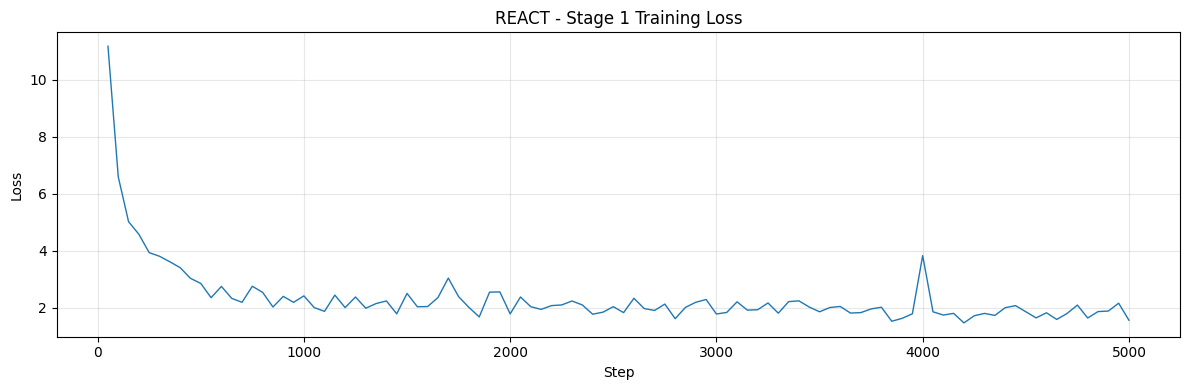

Final loss : 1.5638
Best  loss : 1.4705


In [10]:
# ── Step 8: Plot training loss ──────────────────────────────────────────
import json
import matplotlib.pyplot as plt

log_path = Path(CKPT_DIR) / 'training_log.json'

with open(log_path, 'r') as f:
    history = json.load(f)

steps  = [h['step'] for h in history]
losses = [h['train_loss'] for h in history]

plt.figure(figsize=(12, 4))
plt.plot(steps, losses, linewidth=1)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('REACT - Stage 1 Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Final loss : {losses[-1]:.4f}')
print(f'Best  loss : {min(losses):.4f}')

In [9]:
# ── Step 9: Sanity check on best checkpoint ─────────────────────────────
import json
import torch
import librosa
from pathlib import Path
from src.main.model.main_model import MainModel
from transformers import BartTokenizer, WhisperProcessor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt_path = Path(CKPT_DIR) / 'checkpoint_best.pt'
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
print(f'Best checkpoint — step: {ckpt["step"]} | val_loss: {ckpt["val_loss"]:.4f}')

model = MainModel(
    whispher_model='openai/whisper-small',
    bart_model='facebook/bart-base'
).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

tokenizer = BartTokenizer.from_pretrained('facebook/bart-base')
processor = WhisperProcessor.from_pretrained('openai/whisper-small')

# Load a real test sample
with open('/content/repo/src/data/audio/test_manifest.json', 'r') as f:
    test_entries = json.load(f)

for i in range(min(3, len(test_entries))):
    sample = test_entries[i]
    print(f'\n--- Sample {i+1} ---')
    print(f'Source   : {sample["source_title"][:80]}')
    print(f'Expected : {sample["citation_string"][:80]}')

    waveform, sr = librosa.load(sample['audio_path'], sr=16000)
    audio_features = processor(waveform, sampling_rate=16000, return_tensors='pt').input_features.to(device)

    ctx = f"{sample['source_title']} </s> {sample['source_abstract']}"
    enc = tokenizer(ctx, return_tensors='pt', max_length=512, truncation=True)
    text_ids  = enc['input_ids'].to(device)
    text_mask = enc['attention_mask'].to(device)

    with torch.no_grad():
        out = model.generate(
            audio_features=audio_features,
            text_input_ids=text_ids,
            text_attention_mask=text_mask,
            max_length=64,
            num_beams=3,
        )

    print(f'Generated: {tokenizer.decode(out[0], skip_special_tokens=True)}')

print(f'\nCheckpoints saved to Google Drive at: {CKPT_DIR}')

Best checkpoint — step: 4800 | val_loss: 1.7286


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]


--- Sample 1 ---
Source   : Context-aware LLM-based Safe Control Against Latent Risks
Expected : Zarzà et al., 2023
Generated: Zui et al., 2024

--- Sample 2 ---
Source   : Mucha: Multi-channel based Code Change Representation Learning for Commit Messag
Expected : Cvitkovic et al., 2018
Generated: Zhang et al., 2021

--- Sample 3 ---
Source   : Q-Bridge: Code Translation for Quantum Machine Learning via LLMs
Expected : Agarwal et al., 2025
Generated: Chen et al., 2022

Checkpoints saved to Google Drive at: /content/drive/MyDrive/CiteMind/checkpoints/pretrain
